# Requirements

As follows, don't use "rm rf" like this command, and I include 5 types which cover Rotate 180, Hidden Info, Parker Pazzle, Rotate Overlays and Twisting Squares.  

In [1]:
from google.colab import drive

drive.mount('/content/drive')

FOLDERNAME = "Visual_Anagrams_2024CVPR/baselines/Burgert"
assert FOLDERNAME is not None, "[!] Enter the foldername."

import sys
PROJECT_PATH = f"/content/drive/MyDrive/{FOLDERNAME}"
sys.path.append(PROJECT_PATH)
%cd "{PROJECT_PATH}"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Visual_Anagrams_2024CVPR/baselines/Burgert


In [ ]:
from huggingface_hub import login
import huggingface_hub
token = ""
login(token=token)
print(huggingface_hub.__version__)

from huggingface_hub import hf_hub_download as cached_download

0.31.1


In [3]:
# !git clone https://github.com/RyannDaGreat/Diffusion-Illusions.git "/content/drive/My Drive/Visual_Anagrams_2024CVPR/baselines/Burget"
%cd "/content/drive/MyDrive/Visual_Anagrams_2024CVPR/baselines/Burgert/Diffusion-Illusions"

/content/drive/MyDrive/Visual_Anagrams_2024CVPR/baselines/Burgert/Diffusion-Illusions


In [4]:
# ✅ Step 1: 安装稳定依赖版本
!pip install -q \
  numpy==1.26.4 \
  scipy \
  diffusers==0.27.2 \
  transformers==4.48.0 \
  huggingface_hub==0.31.1 \
  opencv-python==4.6.0.66 \
  imageio==2.33.0 \
  einops==0.4.1 \
  tqdm \
  rp easydict


# pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
# tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.0 which is incompatible.
# dataproc-spark-connect 0.7.3 requires tqdm>=4.67

# ✅ Step 2: 修复 rp 的 numpy 使用问题（np.dtypes）
import numpy as np
if not hasattr(np, "dtypes"):
    np.dtypes = np.dtype

# ✅ Step 3: 验证
# the most important is numpy version, must be 1.26.4
import transformers, rp
import huggingface_hub
print("✅ Transformers:", transformers.__version__)
print("✅ NumPy:", np.__version__)
print("✅ RP path:", rp.__file__)
from huggingface_hub import split_torch_state_dict_into_shards
print("✅ huggingface_hub OK")
print("huggingface_hub.version:", huggingface_hub.__version__)

✅ Transformers: 4.48.0
✅ NumPy: 1.26.4
✅ RP path: /usr/local/lib/python3.11/dist-packages/rp/__init__.py
✅ huggingface_hub OK
huggingface_hub.version: 0.31.1


# Old packages Implementation Repair
- diffusers 0.27.2: huggingface_hub.cached_download -> huggingface_hub.hf_hub_download

- peft and transformers version need to be matched: >=0.15.0 & >=0.48.0

In [5]:
# ✅ Patch diffusers 源码：将 old cached_download 替换为 hf_hub_download
import pathlib

target = pathlib.Path("/usr/local/lib/python3.11/dist-packages/diffusers/utils/dynamic_modules_utils.py")

# 确保文件存在
if target.exists():
    code = target.read_text()
    if "from huggingface_hub import cached_download" in code:
        patched = code.replace(
            "from huggingface_hub import cached_download, hf_hub_download, model_info",
            "from huggingface_hub import hf_hub_download, model_info\ncached_download = hf_hub_download"
        )
        target.write_text(patched)
        print("✅ Patched dynamic_modules_utils.py")
    else:
        print("✅ Diffusers Already patched")
else:
    print("❌ File not found. Is diffusers installed?")

✅ Patched dynamic_modules_utils.py


In [6]:
import numpy as np
if not hasattr(np, "dtypes"):
    np.dtypes = np.dtype  # 临时兼容一些错误包

from rp import *
import rp
import torch
import torch.nn as nn
import source.stable_diffusion as sd
from easydict import EasyDict
from source.learnable_textures import LearnableImageFourier
from source.stable_diffusion_labels import NegativeLabel
from itertools import chain
import time

In [7]:
illusion_configs = [
    {
        "name": "flip.campfire.man",
        "prompts": ["an oil painting of people around a campfire", "an oil painting of an old man"],
        "views": ["identity", "flip"],
    },
    {
        "name": "jigsaw.houseplants.marilyn",
        "prompts": ["an oil painting of houseplants", "an oil painting of marilyn monroe"],
        "views": ["identity", "jigsaw"],
    },
    {
        "name": "inner.einstein.marilyn",
        "prompts": ["an oil painting of albert einstein", "an oil painting of marilyn monroe"],
        "views": ["identity", "inner_circle"],
    },
    {
        "name": "negate.landscape.houseplants",
        "prompts": ["a lithograph of a landscape", "a lithograph of houseplants"],
        "views": ["identity", "negate"],
    },
    {
        "name": "patch.lemur.kangaroo",
        "prompts": ["a pencil sketch of a lemur", "a pencil sketch of a kangaroo"],
        "views": ["identity", "patch_permute"],
    },
    {
        "name": "pixel.duck.rabbit",
        "prompts": ["a mosaic of a duck", "a mosaic of a rabbit"],
        "views": ["identity", "pixel_permute"],
    },
    {
        "name": "skew.tudor.skull",
        "prompts": ["an oil painting of a tudor portrait", "an oil painting of a skull"],
        "views": ["identity", "skew"],
    },
    {
        "name": "skew.taylor.rose",
        "prompts": ["an oil painting of a Taylor Swift", "an oil painting of a rose"],
        "views": ["identity", "skew"],
    },
]


# Rotate 180
prompts for example and customization

In [9]:
#ONLY GOOD PROMPTS HERE
example_prompts = rp.load_yaml_file('source/example_prompts.yaml')
print('Available example prompts:', ', '.join(example_prompts))

#These prompts are all strings - you can replace them with whatever you want! By default it lets you choose from example prompts
#Here are some on the site! It does take some thought to come up with good ideas; the upside-down should look vaguely like the right-side up to work nicely
prompt_a, prompt_b = rp.gather(example_prompts, 'victorial_dress victorial_dress'.split())
prompt_a, prompt_b = rp.gather(example_prompts, 'pencil_giraffe_head pencil_penguin'.split())
# prompt_a, prompt_b = rp.gather(example_prompts, 'sailing_ship sailing_ship'.split())
negative_prompt = ''

print()
print('Negative prompt:',repr(negative_prompt))
print()
print('Chosen prompts:')
print('    prompt_a =', repr(prompt_a)) #This will be right-side up
print('    prompt_b =', repr(prompt_b)) #This will be upside-down

Available example prompts: kitten_in_box, botw_landscape, magic_emma_watson, yorkshire_terrier_santa, norwegian_winter_girl, magic_forest_temple, sailing_ship, bioshock_lighthouse, two_bunnys_hugging, thomas_tank_military, wolf_on_rock, victorial_dress, lolita_dress_magical_elf, pencil_giraffe_head, pencil_penguin, pencil_violin, pencil_orca_whale, pencil_cow, pencil_walrus, pencil_cat_head, pencil_dog_head, ape_with_gun, human_skeleton, gold_coins, golf_ball_in_forest, bear_in_forest, elephant_in_circus, mickey_mouse, mushroom, mario, burger, darth_vader, gandalf, fantasy_city, green_elf_girl, pikachu, spring, fall, winter, summer, miku, pyramids, dinosaur, lipstick, picard, bull_wing, froggo, assasin_creed, moon, minecraft_zombie, pistol, disco_ball, volcano, porche, hawaii_beach, walter_white, dalek, tardis, tennant, weeping_angel

Negative prompt: ''

Chosen prompts:
    prompt_a = 'an intricate detailed hb pencil sketch of a giraffe head'
    prompt_b = 'an intricate detailed hb p

In [10]:
# customized prompts exclude examples
prompt_a = 'an oil painting of a tudor portrait'
prompt_b = 'an oil painting of a skull'

negative_prompt = ''

print()
print('Negative prompt:',repr(negative_prompt))
print()
print('Chosen prompts:')
print('    prompt_a =', repr(prompt_a)) #This will be right-side up
print('    prompt_b =', repr(prompt_b)) #This will be upside-down


Negative prompt: ''

Chosen prompts:
    prompt_a = 'an oil painting of a tudor portrait'
    prompt_b = 'an oil painting of a skull'


## Launcher Process

In [ ]:
# check GPU first
if 's' not in dir():
    model_name="CompVis/stable-diffusion-v1-4"
    gpu='cuda:0'
    s=sd.StableDiffusion(gpu,model_name)
device=s.device

In [ ]:
label_a = NegativeLabel(prompt_a,negative_prompt)
label_b = NegativeLabel(prompt_b,negative_prompt)

In [ ]:
#Image Parametrization and Initialization (this section takes vram)

#Select Learnable Image Size (this has big VRAM implications!):
#Note: We use implicit neural representations for better image quality
#They're previously used in our paper "TRITON: Neural Neural Textures make Sim2Real Consistent" (see tritonpaper.github.io)
# ... and that representation is based on Fourier Feature Networks (see bmild.github.io/fourfeat)
learnable_image_maker = lambda: LearnableImageFourier(height=256, width=256, hidden_dim=256, num_features=128).to(s.device); SIZE=256
# learnable_image_maker = lambda: LearnableImageFourier(height=512,width=512,num_features=256,hidden_dim=256,scale=20).to(s.device);SIZE=512

image=learnable_image_maker()

In [ ]:
learnable_image_a=lambda: image() #Right-side up
learnable_image_b=lambda: image().rot90(k=2,dims=[1,2]) #Upside-down

optim=torch.optim.SGD(image.parameters(),lr=1e-4)

In [ ]:
labels=[label_a,label_b]
learnable_images=[learnable_image_a,learnable_image_b]

#The weight coefficients for each prompt. For example, if we have [0,1], then only the upside-down mode will be optimized
weights=[1,1]

weights=rp.as_numpy_array(weights)
weights=weights/weights.sum()
weights=weights*len(weights)

In [ ]:
#For saving a timelapse
ims=[]

In [ ]:
def get_display_image():
    return rp.tiled_images(
        [
            rp.as_numpy_image(learnable_image_a()),
            rp.as_numpy_image(learnable_image_b()),
        ],
        length=len(learnable_images),
        border_thickness=0,
    )

Every 200 iterations we display an image in the form [image_a, image_b], where
    image_a = (the right-side up image)
    image_b = (image_a, but upside down)

Interrupt the kernel at any time to return the currently displayed image
You can run this cell again to resume training later on

Please expect this to take quite a while to get good images (especially on the slower Colab GPU's)! The longer you wait the better they'll be


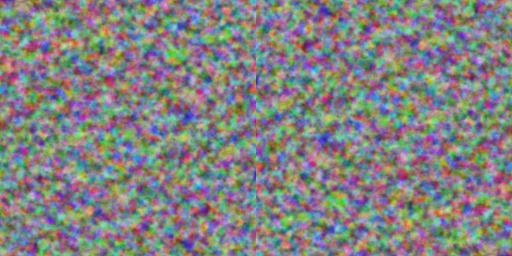

Status: ETR=0:10:49.637215      ETA=0:12:29.581402      T=0:01:39.944187        Progress: 200/1500

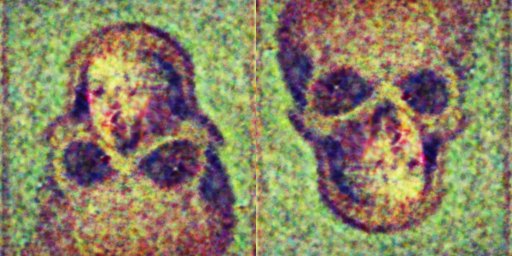

Status: ETR=0:09:09.888092      ETA=0:12:29.847398      T=0:03:19.959306        Progress: 400/1500

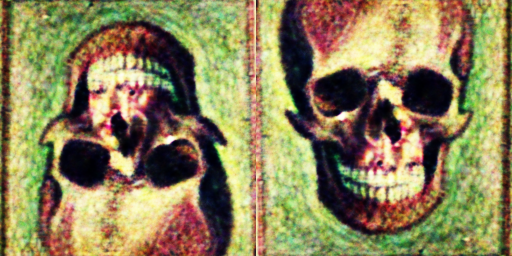

Status: ETR=0:07:29.988583      ETA=0:12:29.980972      T=0:04:59.992389        Progress: 600/1500

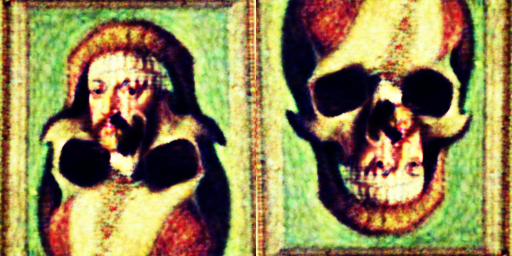

Status: ETR=0:05:50.017503      ETA=0:12:30.037507      T=0:06:40.020004        Progress: 800/1500

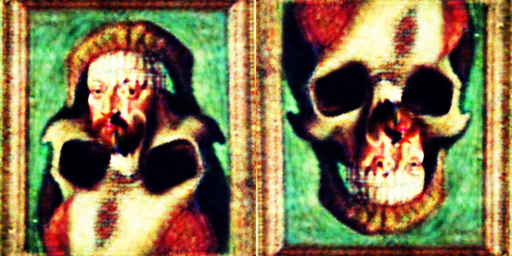

Status: ETR=0:04:10.021988      ETA=0:12:30.065963      T=0:08:20.043976        Progress: 1000/1500

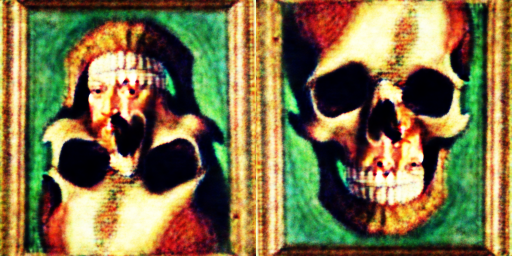

Status: ETR=0:02:30.018689      ETA=0:12:30.093447      T=0:10:00.074757        Progress: 1200/1500

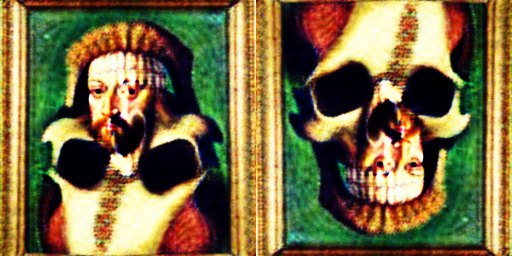

Status: ETR=0:00:50.007206      ETA=0:12:30.108097      T=0:11:40.100890        Progress: 1400/1500

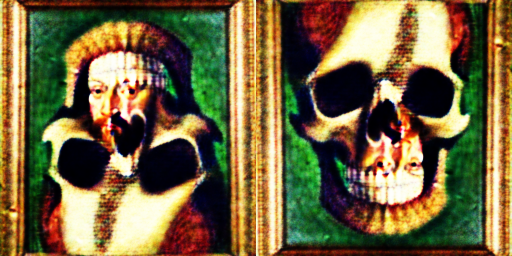

Status: ETR=0:00:00.500096      ETA=0:12:30.144482      T=0:12:29.644385        Progress: 1499/1500

In [ ]:
NUM_ITER=1500

#Set the minimum and maximum noise timesteps for the dream loss (aka score distillation loss)
s.max_step=MAX_STEP=990
s.min_step=MIN_STEP=10

display_eta=rp.eta(NUM_ITER, title='Status')

DISPLAY_INTERVAL = 200

print('Every %i iterations we display an image in the form [image_a, image_b], where'%DISPLAY_INTERVAL)
print('    image_a = (the right-side up image)')
print('    image_b = (image_a, but upside down)')
print()
print('Interrupt the kernel at any time to return the currently displayed image')
print('You can run this cell again to resume training later on')
print()
print('Please expect this to take quite a while to get good images (especially on the slower Colab GPU\'s)! The longer you wait the better they\'ll be')

try:
    for iter_num in range(NUM_ITER):
        display_eta(iter_num) #Print the remaining time

        preds=[]
        for label,learnable_image,weight in rp.random_batch(list(zip(labels,learnable_images,weights)), batch_size=1):
            pred=s.train_step(
                label.embedding,
                learnable_image()[None],

                #PRESETS (uncomment one):
                noise_coef=.1*weight,guidance_scale=60,#10
                # noise_coef=0,image_coef=-.01,guidance_scale=50,
                # noise_coef=0,image_coef=-.005,guidance_scale=50,
                # noise_coef=.1,image_coef=-.010,guidance_scale=50,
                # noise_coef=.1,image_coef=-.005,guidance_scale=50,
                # noise_coef=.1*weight, image_coef=-.005*weight, guidance_scale=50,
            )
            preds+=list(pred)

        with torch.no_grad():
            if iter_num and not iter_num%(DISPLAY_INTERVAL*50):
                #Wipe the slate every 50 displays so they don't get cut off
                from IPython.display import clear_output
                clear_output()

            if not iter_num%DISPLAY_INTERVAL:
                im = get_display_image()
                ims.append(im)
                rp.display_image(im)

        optim.step()
        optim.zero_grad()
except KeyboardInterrupt:
    print()
    print('Interrupted early at iteration %i'%iter_num)
    im = get_display_image()
    ims.append(im)
    rp.display_image(im)

Right-side up image:


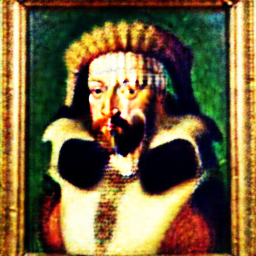

Upside-down image:


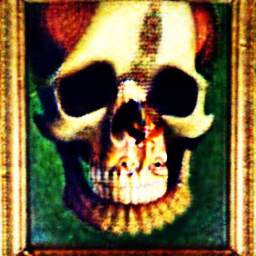

In [ ]:
print('Right-side up image:')
rp.display_image(rp.as_numpy_image(learnable_image_a()))

print('Upside-down image:')
rp.display_image(rp.as_numpy_image(learnable_image_b()))

In [ ]:
def save_png(name, sub_folder, output_folder):
    folder=f"{output_folder}/{sub_folder}/{name}"
    if rp.path_exists(folder):
        folder+='_%i'%time.time()
    rp.make_directory(folder)
    ims_names=['ims_%04i.png'%i for i in range(len(ims))]
    with rp.SetCurrentDirectoryTemporarily(folder):
        rp.save_images(ims,ims_names,show_progress=True)
    print()
    print('Saved timelapse to folder:',repr(folder))


sub_folder = "skew.tudor.skull"
out = "/content/drive/MyDrive/Visual_Anagrams_2024CVPR/baselines/Burgert/outputs"
save_png('-'.join([prompt_a,prompt_b]), sub_folder=sub_folder, output_folder=out) #You can give it a good custom name if you want!

Saving Images: Done! Did 8 items in 0:00:00.088371
rp.save_images: Done! Saved 8 images in 0.090 seconds

Saved timelapse to folder: '/content/drive/MyDrive/Visual_Anagrams_2024CVPR/baselines/Burgert/outputs/skew.tudor.skull/an oil painting of a tudor portrait-an oil painting of a skull'


In [ ]:
def save_run(name):
    folder="untracked/skew.tudor.skull/%s"%name
    if rp.path_exists(folder):
        folder+='_%i'%time.time()
    rp.make_directory(folder)
    ims_names=['ims_%04i.png'%i for i in range(len(ims))]
    with rp.SetCurrentDirectoryTemporarily(folder):
        rp.save_images(ims,ims_names,show_progress=True)
    print()
    print('Saved timelapse to folder:',repr(folder))

save_run('-'.join([prompt_a,prompt_b])) #You can give it a good custom name if you want!

Saving Images: Done! Did 18 items in 0:00:00.283249
rp.save_images: Done! Saved 18 images in 0.286 seconds

Saved timelapse to folder: 'untracked/flippy_illusion_runs/an intricate detailed hb pencil sketch of a giraffe head-an intricate detailed hb pencil sketch of a penguin_1748005518'


# Hidden Info

In [ ]:
#ONLY GOOD PROMPTS HERE
example_prompts = rp.load_yaml_file('source/example_prompts.yaml')
print('Available example prompts:', ', '.join(example_prompts))

#These prompts are all strings - you can replace them with whatever you want! By default it lets you choose from example prompts
prompt_a, prompt_b, prompt_c, prompt_d, prompt_z = rp.gather(example_prompts, 'miku froggo lipstick kitten_in_box darth_vader'.split())
#Prompts a,b,c,d are the normal looking images
#Prompt z is the hidden image you get when you overlay them all on top of each other

negative_prompt = ''

print()
print('Negative prompt:',repr(negative_prompt))
print()
print('Chosen prompts:')
print('    prompt_a =', repr(prompt_a))
print('    prompt_b =', repr(prompt_b))
print('    prompt_c =', repr(prompt_c))
print('    prompt_d =', repr(prompt_d))
print('    prompt_z =', repr(prompt_z))

Available example prompts: kitten_in_box, botw_landscape, magic_emma_watson, yorkshire_terrier_santa, norwegian_winter_girl, magic_forest_temple, sailing_ship, bioshock_lighthouse, two_bunnys_hugging, thomas_tank_military, wolf_on_rock, victorial_dress, lolita_dress_magical_elf, pencil_giraffe_head, pencil_penguin, pencil_violin, pencil_orca_whale, pencil_cow, pencil_walrus, pencil_cat_head, pencil_dog_head, ape_with_gun, human_skeleton, gold_coins, golf_ball_in_forest, bear_in_forest, elephant_in_circus, mickey_mouse, mushroom, mario, burger, darth_vader, gandalf, fantasy_city, green_elf_girl, pikachu, spring, fall, winter, summer, miku, pyramids, dinosaur, lipstick, picard, bull_wing, froggo, assasin_creed, moon, minecraft_zombie, pistol, disco_ball, volcano, porche, hawaii_beach, walter_white, dalek, tardis, tennant, weeping_angel

Negative prompt: ''

Chosen prompts:
    prompt_a = 'Hatsune miku, gorgeous, amazing, elegant, intricate, highly detailed, digital painting, artstation, 

You can change your prompts as many as you want.

In [ ]:
# customized prompts
prompt_a = 'Asuka Langley from Evangelion, stunning red plug suit, elegant, beautiful lighting, sharp focus, intricate anime portrait, digital painting, artstation, concept art, detailed brushwork, rossdraws and wlop style'
prompt_b = 'A rabbit wearing a tiny chef hat baking cupcakes in a rustic kitchen, charming, hyper detailed, cinematic lighting, digital illustration, trending on artstation, octane render, 8k'
prompt_c = 'luxury wristwatch on black leather surface, product photo, studio lighting, 2 0 2 2, glossy commercial aesthetic, high-end brand photography, macro shot'
prompt_d = 'A sleepy shiba inu puppy in a sunflower field at sunset, cute overload, dslr photo, photorealistic, warm tones, taken with Nikon Z9'
prompt_z = 'photo of ultra realistic Iron Man battle damaged suit, dramatic light, cinematic slow-mo feel, low angle, 6k, hyper realistic, intricate armor reflections, high impact cinematic keyframe, trending on artstation'

negative_prompt = ''

## Launcher Process

In [ ]:
# check GPU first
if 's' not in dir():
    model_name="CompVis/stable-diffusion-v1-4"
    gpu='cuda:0'
    s=sd.StableDiffusion(gpu,model_name)
device=s.device

In [ ]:
label_a = NegativeLabel(prompt_a,negative_prompt)
label_b = NegativeLabel(prompt_b,negative_prompt)
label_c = NegativeLabel(prompt_c,negative_prompt)
label_d = NegativeLabel(prompt_d,negative_prompt)
label_z = NegativeLabel(prompt_z,negative_prompt)

In [ ]:
#Image Parametrization and Initialization (this section takes vram)

#Select Learnable Image Size (this has big VRAM implications!):
#Note: We use implicit neural representations for better image quality
#They're previously used in our paper "TRITON: Neural Neural Textures make Sim2Real Consistent" (see tritonpaper.github.io)
# ... and that representation is based on Fourier Feature Networks (see bmild.github.io/fourfeat)
learnable_image_maker = lambda: LearnableImageFourier(height=256, width=256, hidden_dim=256, num_features=128).to(s.device); SIZE=256
# learnable_image_maker = lambda: LearnableImageFourier(height=512,width=512,num_features=256,hidden_dim=256,scale=20).to(s.device);SIZE=512

image_a=learnable_image_maker()
image_b=learnable_image_maker()
image_c=learnable_image_maker()
image_d=learnable_image_maker()

In [ ]:
CLEAN_MODE = True # If it's False, we augment the images by randomly simulating how good a random printer might be when making the overlays...

def simulate_overlay(a,b,c,d):
    if CLEAN_MODE:
        exp=1
        brightness=3
        black=0
    else:
        exp=rp.random_float(.5,1)
        brightness=rp.random_float(1,5)
        black=rp.random_float(0,.5)
        bottom=rp.blend(bottom,black,rp.random_float())
        top=rp.blend(top,black,rp.random_float())
    return (a**exp * b**exp *c**exp * d**exp * brightness).clamp(0,99).tanh()

learnable_image_a=lambda: image_a()
learnable_image_b=lambda: image_b()
learnable_image_c=lambda: image_c()
learnable_image_d=lambda: image_d()
learnable_image_z=lambda: simulate_overlay(image_a(), image_b(), image_c(), image_d())

params=chain(
    image_a.parameters(),
    image_b.parameters(),
    image_c.parameters(),
    image_d.parameters(),
)
optim=torch.optim.SGD(params,lr=1e-4)

In [ ]:
labels=[label_a, label_b, label_c, label_d, label_z]
learnable_images=[learnable_image_a,learnable_image_b,learnable_image_c,learnable_image_d,learnable_image_z]

#The weight coefficients for each prompt. For example, if we have [1,1,1,1,5], then the hidden prompt (prompt_z) will be prioritized
weights=[1,1,1,1,1]

weights=rp.as_numpy_array(weights)
weights=weights/weights.sum()
weights=weights*len(weights)

In [ ]:
#For saving a timelapse
ims=[]

In [ ]:
def get_display_image():
    return rp.tiled_images(
        [
            *[rp.as_numpy_image(image()) for image in learnable_images],
        ],
        length=len(learnable_images),
        border_thickness=0,
    )

In [ ]:
NUM_ITER=3000

#Set the minimum and maximum noise timesteps for the dream loss (aka score distillation loss)
s.max_step=MAX_STEP=990
s.min_step=MIN_STEP=10

display_eta=rp.eta(NUM_ITER, title='Status: ')

DISPLAY_INTERVAL = 200

print('Every %i iterations we display an image in the form [image_a, image_b, image_c, image_d, image_z] where'%DISPLAY_INTERVAL)
print('    image_z = image_a * image_b * image_c * image_d')
print()
print('Interrupt the kernel at any time to return the currently displayed image')
print('You can run this cell again to resume training later on')
print()
print('Please expect this to take hours to get good images (especially on the slower Colab GPU\'s! The longer you wait the better they\'ll be')

try:
    for iter_num in range(NUM_ITER):
        display_eta(iter_num) #Print the remaining time

        preds=[]
        for label,learnable_image,weight in rp.random_batch(list(zip(labels,learnable_images,weights)), batch_size=1):
            pred=s.train_step(
                label.embedding,
                learnable_image()[None],

                #PRESETS (uncomment one):
                noise_coef=.1*weight,guidance_scale=60,#10
                # noise_coef=0,image_coef=-.01,guidance_scale=50,
                # noise_coef=0,image_coef=-.005,guidance_scale=50,
                # noise_coef=.1,image_coef=-.010,guidance_scale=50,
                # noise_coef=.1,image_coef=-.005,guidance_scale=50,
                # noise_coef=.1*weight, image_coef=-.005*weight, guidance_scale=50,
            )
            preds+=list(pred)

        with torch.no_grad():
            if iter_num and not iter_num%(DISPLAY_INTERVAL*50):
                #Wipe the slate every 50 displays so they don't get cut off
                from IPython.display import clear_output
                clear_output()

            if not iter_num%DISPLAY_INTERVAL:
                im = get_display_image()
                ims.append(im)
                rp.display_image(im)

        optim.step()
        optim.zero_grad()
except KeyboardInterrupt:
    print()
    print('Interrupted early at iteration %i'%iter_num)
    im = get_display_image()
    ims.append(im)
    rp.display_image(im)


Output hidden; open in https://colab.research.google.com to view.

Image A


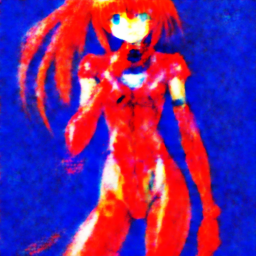

Image B


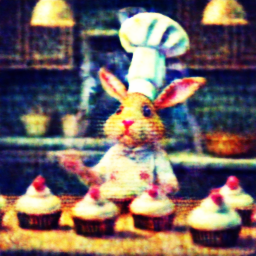

Image C


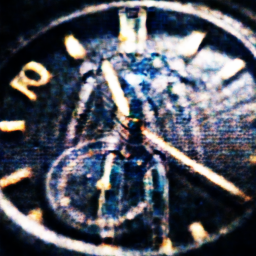

Image D


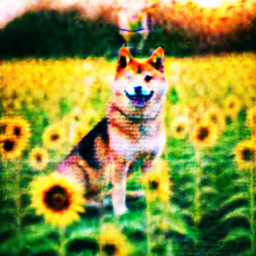

Image Z


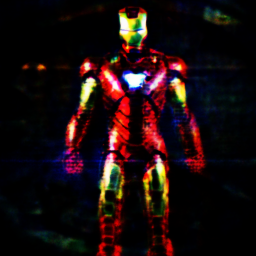

In [ ]:
print('Image A')
rp.display_image(rp.as_numpy_image(learnable_image_a()))

print('Image B')
rp.display_image(rp.as_numpy_image(learnable_image_b()))

print('Image C')
rp.display_image(rp.as_numpy_image(learnable_image_c()))

print('Image D')
rp.display_image(rp.as_numpy_image(learnable_image_d()))

print('Image Z')
rp.display_image(rp.as_numpy_image(learnable_image_z()))

In [ ]:
def save_png(name, sub_folder, output_folder):
    folder=f"{output_folder}/{sub_folder}/{name}"
    if rp.path_exists(folder):
        folder+='_%i'%time.time()
    rp.make_directory(folder)
    ims_names=['ims_%04i.png'%i for i in range(len(ims))]
    with rp.SetCurrentDirectoryTemporarily(folder):
        rp.save_images(ims,ims_names,show_progress=True)
    print()
    print('Saved timelapse to folder:',repr(folder))


sub_folder = "Hidden_MIKU_frog_photo2018_kitchen"
out = "/content/drive/MyDrive/Visual_Anagrams_2024CVPR/baselines/Burgert/outputs"
save_png('Hidden_Mixed_Characters', sub_folder=sub_folder, output_folder=out) #You can give it a good custom name if you want!

Saving Images: Done! Did 12 items in 0:00:00.094658
rp.save_images: Done! Saved 12 images in 0.097 seconds

Saved timelapse to folder: '/content/drive/MyDrive/Visual_Anagrams_2024CVPR/baselines/Burgert/outputs/Hidden_MIKU_frog_photo2018_kitchen/Hidden_Mixed_Characters'


In [ ]:
# Customized configuration
def save_png(name, sub_folder, output_folder):
    folder=f"{output_folder}/{sub_folder}/{name}"
    if rp.path_exists(folder):
        folder+='_%i'%time.time()
    rp.make_directory(folder)
    ims_names=['ims_%04i.png'%i for i in range(len(ims))]
    with rp.SetCurrentDirectoryTemporarily(folder):
        rp.save_images(ims,ims_names,show_progress=True)
    print()
    print('Saved timelapse to folder:',repr(folder))


sub_folder = "Hidden_Asuka_rabbit_wristwatch_puppy_Iron_Man"
out = "/content/drive/MyDrive/Visual_Anagrams_2024CVPR/baselines/Burgert/outputs"
save_png('Hidden_Mixed_Characters', sub_folder=sub_folder, output_folder=out) #You can give it a good custom name if you want!

Saving Images: Done! Did 18 items in 0:00:00.436928
rp.save_images: Done! Saved 18 images in 0.440 seconds

Saved timelapse to folder: '/content/drive/MyDrive/Visual_Anagrams_2024CVPR/baselines/Burgert/outputs/Hidden_Asuka_rabbit_wristwatch_puppy_Iron_Man/Hidden_Mixed_Characters'


# Parker_Puzzle

In [ ]:
#SET YOUR PROMPTS HERE

prompt_a = "A ceramic coffee mug with handle viewed from side and steam rising. Beautiful 4k photography unreal engine 3d "
prompt_b = "A donut. A shiny frosted chocolate donut. Beautiful 4k photography unreal engine 3d"


#Optional: Specify what you DON'T want to see
negative_prompt = 'blurry ugly'

print()
print('Negative prompt:',repr(negative_prompt))
print()
print('Chosen prompts:')
print('    prompt_a =', repr(prompt_a)) #This will be right-side up
print('    prompt_b =', repr(prompt_b)) #This will be upside-down


Negative prompt: 'blurry ugly'

Chosen prompts:
    prompt_a = 'A ceramic coffee mug with handle viewed from side and steam rising. Beautiful 4k photography unreal engine 3d '
    prompt_b = 'A donut. A shiny frosted chocolate donut. Beautiful 4k photography unreal engine 3d'


In [ ]:
# customized

prompt_a = "A vintage typewriter on a wooden desk under a rainy window. Moody ambient light, nostalgic atmosphere, 4k ultra-realistic photography, cinematic lighting, unreal engine render"

prompt_b = "A modern silver laptop glowing in a dim room with rain outside the window. Ambient screen light, digital serenity, 4k photography, unreal engine 3d, volumetric lighting"

# Optional: Specify what you DON'T want to see
negative_prompt = 'blurry ugly cartoon low-res cluttered artifacts'

print()
print('Negative prompt:', repr(negative_prompt))
print()
print('Chosen prompts:')
print('    prompt_a =', repr(prompt_a))  # Right-side up
print('    prompt_b =', repr(prompt_b))  # Upside-down



Negative prompt: 'blurry ugly cartoon low-res cluttered artifacts'

Chosen prompts:
    prompt_a = 'A vintage typewriter on a wooden desk under a rainy window. Moody ambient light, nostalgic atmosphere, 4k ultra-realistic photography, cinematic lighting, unreal engine render'
    prompt_b = 'A modern silver laptop glowing in a dim room with rain outside the window. Ambient screen light, digital serenity, 4k photography, unreal engine 3d, volumetric lighting'


In [ ]:
# customized

prompt_a = "A painting of Van Gogh's bedroom, colorful, minimal furniture, wooden bed and chairs, perspective view, symmetrical layout, artstation, 4k, octane render"

prompt_b = "An intricately detailed painting of a cozy animal nest styled like a bedroom, with hay bed, wooden furniture, natural lighting, similar layout, artstation, 4k, cinematic atmosphere"

# Optional: Specify what you DON'T want to see
negative_prompt = 'distorted messy overexposed unstructured'

print()
print('Negative prompt:', repr(negative_prompt))
print()
print('Chosen prompts:')
print('    prompt_a =', repr(prompt_a))  # Right-side up
print('    prompt_b =', repr(prompt_b))  # Upside-down



Negative prompt: 'distorted messy overexposed unstructured'

Chosen prompts:
    prompt_a = "A painting of Van Gogh's bedroom, colorful, minimal furniture, wooden bed and chairs, perspective view, symmetrical layout, artstation, 4k, octane render"
    prompt_b = 'An intricately detailed painting of a cozy animal nest styled like a bedroom, with hay bed, wooden furniture, natural lighting, similar layout, artstation, 4k, cinematic atmosphere'


## Launcher Process

In [ ]:
if 's' not in dir():
    #You can select the original Stable Diffusion 1.5 or some dreambooth of it
    model_name="CompVis/stable-diffusion-v1-4"
    model_name="runwayml/stable-diffusion-v1-5"
    # model_name="nitrosocke/Arcane-Diffusion"
    gpu=rp.select_torch_device()
    s=sd.StableDiffusion(gpu,model_name)
device=s.device

In [ ]:
label_a = NegativeLabel(prompt_a,negative_prompt)
label_b = NegativeLabel(prompt_b,negative_prompt)

In [ ]:
#Image Parametrization and Initialization (this section takes vram)

#Select Learnable Image Size (this has big VRAM implications!):
#Note: We use implicit neural representations for better image quality
#They're previously used in our paper "TRITON: Neural Neural Textures make Sim2Real Consistent" (see tritonpaper.github.io)
# ... and that representation is based on Fourier Feature Networks (see bmild.github.io/fourfeat)
learnable_image_maker = lambda: LearnableImageFourier(height=256,width=256,num_features=256,hidden_dim=256,scale=10).to(s.device);SIZE=256

image=learnable_image_maker()

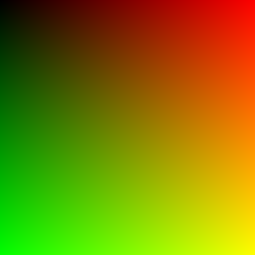

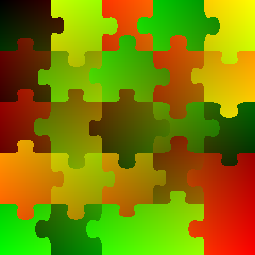

In [ ]:
import torch
import torch.nn.functional as F

#This is the puzzle Matt used in his video!
uv_map_b = rp.load_image("https://github.com/RyannDaGreat/Images/blob/master/test_images/parker_puzzle_uv_map.png?raw=true")
uv_map_a = rp.get_identity_uv_map(*rp.get_image_dimensions(uv_map_b))

rp.display_image(uv_map_a)
rp.display_image(uv_map_b)

learnable_image_a = lambda: rp.apply_uv_map(image(), uv_map_a)
learnable_image_b = lambda: rp.apply_uv_map(image(), uv_map_b)

optim=torch.optim.SGD(image.parameters(),lr=1e-4)

In [ ]:
labels=[label_a,label_b]
learnable_images=[learnable_image_a,learnable_image_b]

#The weight coefficients for each prompt. For example, if we have [0,1], then only the upside-down mode will be optimized
weights=[1,1]

weights=rp.as_numpy_array(weights)
weights=weights/weights.sum()
weights=weights*len(weights)

In [ ]:
ims=[]
def get_display_image():
    return rp.tiled_images(
        [
            rp.as_numpy_image(learnable_image_a()),
            rp.as_numpy_image(learnable_image_b()),
        ],
        length=len(learnable_images),
        border_thickness=0,
    )

In [ ]:
#For saving a timelapse
NUM_ITER=2500

#Set the minimum and maximum noise timesteps for the dream loss (aka score distillation loss)
s.max_step=MAX_STEP=990
s.min_step=MIN_STEP=10

television = rp.JupyterDisplayChannel()
television.display()

display_eta=rp.eta(NUM_ITER, title='Status')

DISPLAY_INTERVAL = 200

print('Every %i iterations we display an image in the form [image_a, image_b], where'%DISPLAY_INTERVAL)
print('    image_a = (the right-side up image)')
print('    image_b = (image_a, but upside down)')
print()
print('Interrupt the kernel at any time to return the currently displayed image')
print('You can run this cell again to resume training later on')
print()
print('Please expect this to take quite a while to get good images (especially on the slower Colab GPU\'s)! The longer you wait the better they\'ll be')

try:
    for iter_num in range(NUM_ITER):
        display_eta(iter_num) #Print the remaining time

        preds=[]
        for label,learnable_image,weight in rp.random_batch(list(zip(labels,learnable_images,weights)), batch_size=1):
            pred=s.train_step(
                label.embedding,
                learnable_image()[None],

                #PRESETS (uncomment one):
                noise_coef=.1*weight,guidance_scale=100,#10
                # noise_coef=0,image_coef=-.01,guidance_scale=50,
                # noise_coef=0,image_coef=-.005,guidance_scale=50,
                # noise_coef=.1,image_coef=-.010,guidance_scale=50,
                # noise_coef=.1,image_coef=-.005,guidance_scale=50,
                # noise_coef=.1*weight, image_coef=-.005*weight, guidance_scale=50,
            )
            preds+=list(pred)

        with torch.no_grad():
            if iter_num and not iter_num%(DISPLAY_INTERVAL*50):
                #Wipe the slate every 50 displays so they don't get cut off
                from IPython.display import clear_output
                clear_output()

            if not iter_num%(DISPLAY_INTERVAL//4):
                im = get_display_image()
                ims.append(im)
                television.update(im)

                if not iter_num%DISPLAY_INTERVAL:
                    rp.display_image(im)

        optim.step()
        optim.zero_grad()
except KeyboardInterrupt:
    print()
    print('Interrupted early at iteration %i'%iter_num)
    im = get_display_image()
    ims.append(im)
    rp.display_image(im)

Output hidden; open in https://colab.research.google.com to view.

Unsolved Image:


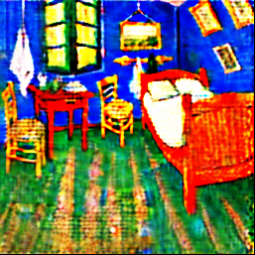

Solved Image:


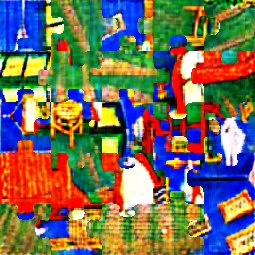

In [ ]:
print('Unsolved Image:')
rp.display_image(rp.as_numpy_image(learnable_image_a()))

print('Solved Image:')
rp.display_image(rp.as_numpy_image(learnable_image_b()))

In [ ]:
def save_png(name, sub_folder, output_folder):
    folder=f"{output_folder}/{sub_folder}/{name}"
    if rp.path_exists(folder):
        folder+='_%i'%time.time()
    rp.make_directory(folder)
    ims_names=['ims_%04i.png'%i for i in range(len(ims))]
    with rp.SetCurrentDirectoryTemporarily(folder):
        rp.save_images(ims,ims_names,show_progress=True)
    print()
    print('Saved timelapse to folder:',repr(folder))


sub_folder = "parker_puzzle_food_and_drink"
out = "/content/drive/MyDrive/Visual_Anagrams_2024CVPR/baselines/Burgert/outputs"
save_png('donut_coffee_mug', sub_folder=sub_folder, output_folder=out) #You can give it a good custom name if you want!

Saving Images: Done! Did 40 items in 0:00:00.370962
rp.save_images: Done! Saved 40 images in 0.374 seconds

Saved timelapse to folder: '/content/drive/MyDrive/Visual_Anagrams_2024CVPR/baselines/Burgert/outputs/parker_puzzle_food_and_drink/donut_coffee_mug'


In [ ]:
# customized
def save_png(name, sub_folder, output_folder):
    folder=f"{output_folder}/{sub_folder}/{name}"
    if rp.path_exists(folder):
        folder+='_%i'%time.time()
    rp.make_directory(folder)
    ims_names=['ims_%04i.png'%i for i in range(len(ims))]
    with rp.SetCurrentDirectoryTemporarily(folder):
        rp.save_images(ims,ims_names,show_progress=True)
    print()
    print('Saved timelapse to folder:',repr(folder))


sub_folder = "parker_puzzle_vintage_modern"
out = "/content/drive/MyDrive/Visual_Anagrams_2024CVPR/baselines/Burgert/outputs"
save_png('laptop_typewriter', sub_folder=sub_folder, output_folder=out) #You can give it a good custom name if you want!

Saving Images: Done! Did 40 items in 0:00:00.330491
rp.save_images: Done! Saved 40 images in 0.334 seconds

Saved timelapse to folder: '/content/drive/MyDrive/Visual_Anagrams_2024CVPR/baselines/Burgert/outputs/parker_puzzle_vintage_modern/laptop_typewriter'


In [ ]:
# customized
def save_png(name, sub_folder, output_folder):
    folder=f"{output_folder}/{sub_folder}/{name}"
    if rp.path_exists(folder):
        folder+='_%i'%time.time()
    rp.make_directory(folder)
    ims_names=['ims_%04i.png'%i for i in range(len(ims))]
    with rp.SetCurrentDirectoryTemporarily(folder):
        rp.save_images(ims,ims_names,show_progress=True)
    print()
    print('Saved timelapse to folder:',repr(folder))


sub_folder = "parker_puzzle_Van_Gogh_Nest"
out = "/content/drive/MyDrive/Visual_Anagrams_2024CVPR/baselines/Burgert/outputs"
save_png('Van_Gogh_Nest', sub_folder=sub_folder, output_folder=out) #You can give it a good custom name if you want!

Saving Images: Done! Did 50 items in 0:00:00.430639
rp.save_images: Done! Saved 50 images in 0.434 seconds

Saved timelapse to folder: '/content/drive/MyDrive/Visual_Anagrams_2024CVPR/baselines/Burgert/outputs/parker_puzzle_Van_Gogh_Nest/Van_Gogh_Nest'


# Rotation Overlays

In [ ]:
#ONLY GOOD PROMPTS HERE
example_prompts = rp.load_yaml_file('source/example_prompts.yaml')
print('Available example prompts:', ', '.join(example_prompts))

#These prompts are all strings - you can replace them with whatever you want! By default it lets you choose from example prompts
prompt_w, prompt_x, prompt_y, prompt_z = rp.gather(example_prompts, 'miku froggo lipstick pyramids'.split())

negative_prompt = ''

print()
print('Negative prompt:',repr(negative_prompt))
print()
print('Chosen prompts:')
print('    prompt_w =', repr(prompt_w))
print('    prompt_x =', repr(prompt_x))
print('    prompt_y =', repr(prompt_y))
print('    prompt_z =', repr(prompt_z))

Available example prompts: kitten_in_box, botw_landscape, magic_emma_watson, yorkshire_terrier_santa, norwegian_winter_girl, magic_forest_temple, sailing_ship, bioshock_lighthouse, two_bunnys_hugging, thomas_tank_military, wolf_on_rock, victorial_dress, lolita_dress_magical_elf, pencil_giraffe_head, pencil_penguin, pencil_violin, pencil_orca_whale, pencil_cow, pencil_walrus, pencil_cat_head, pencil_dog_head, ape_with_gun, human_skeleton, gold_coins, golf_ball_in_forest, bear_in_forest, elephant_in_circus, mickey_mouse, mushroom, mario, burger, darth_vader, gandalf, fantasy_city, green_elf_girl, pikachu, spring, fall, winter, summer, miku, pyramids, dinosaur, lipstick, picard, bull_wing, froggo, assasin_creed, moon, minecraft_zombie, pistol, disco_ball, volcano, porche, hawaii_beach, walter_white, dalek, tardis, tennant, weeping_angel

Negative prompt: ''

Chosen prompts:
    prompt_w = 'Hatsune miku, gorgeous, amazing, elegant, intricate, highly detailed, digital painting, artstation, 

In [ ]:
# customized
prompt_w = 'A photorealistic portrait of a samurai robot warrior, detailed cybernetic armor, glowing eyes, dramatic lighting, sharp focus, digital painting, trending on ArtStation, 8k render, concept art by paul chadeisson and beeple'
prompt_x = 'A majestic phoenix flying across a sunset sky, wings spread wide, fire trailing behind, digital illustration, vivid colors, cinematic atmosphere, octane render, 8k, concept art, art by sakimichan and rossdraws'
prompt_y = 'A futuristic glass bottle of perfume, floating in zero gravity, minimalistic design, product shot, hyperreal render, photography inspired, 2025 campaign'
prompt_z = 'An underwater city of jellyfish buildings, glowing neon lights, bio-luminescent structures, deep ocean mood, digital concept art, unreal engine, highly detailed, artstation trending, 8k resolution, sci-fi masterpiece'

negative_prompt = ''

print()
print('Negative prompt:', repr(negative_prompt))
print()
print('Chosen prompts:')
print('    prompt_w =', repr(prompt_w))
print('    prompt_x =', repr(prompt_x))
print('    prompt_y =', repr(prompt_y))
print('    prompt_z =', repr(prompt_z))



Negative prompt: ''

Chosen prompts:
    prompt_w = 'A photorealistic portrait of a samurai robot warrior, detailed cybernetic armor, glowing eyes, dramatic lighting, sharp focus, digital painting, trending on ArtStation, 8k render, concept art by paul chadeisson and beeple'
    prompt_x = 'A majestic phoenix flying across a sunset sky, wings spread wide, fire trailing behind, digital illustration, vivid colors, cinematic atmosphere, octane render, 8k, concept art, art by sakimichan and rossdraws'
    prompt_y = 'A futuristic glass bottle of perfume, floating in zero gravity, minimalistic design, product shot, hyperreal render, photography inspired, 2025 campaign'
    prompt_z = 'An underwater city of jellyfish buildings, glowing neon lights, bio-luminescent structures, deep ocean mood, digital concept art, unreal engine, highly detailed, artstation trending, 8k resolution, sci-fi masterpiece'


## Launcher Process

In [ ]:
if 's' not in dir():
    model_name="CompVis/stable-diffusion-v1-4"
    gpu='cuda:0'
    s=sd.StableDiffusion(gpu,model_name)
device=s.device

In [ ]:
label_w = NegativeLabel(prompt_w,negative_prompt)
label_x = NegativeLabel(prompt_x,negative_prompt)
label_y = NegativeLabel(prompt_y,negative_prompt)
label_z = NegativeLabel(prompt_z,negative_prompt)

In [ ]:
#Image Parametrization and Initialization (this section takes vram)

#Select Learnable Image Size (this has big VRAM implications!):
#Note: We use implicit neural representations for better image quality
#They're previously used in our paper "TRITON: Neural Neural Textures make Sim2Real Consistent" (see tritonpaper.github.io)
# ... and that representation is based on Fourier Feature Networks (see bmild.github.io/fourfeat)
learnable_image_maker = lambda: LearnableImageFourier(height=256, width=256, hidden_dim=256, num_features=128).to(s.device); SIZE=256
# learnable_image_maker = lambda: LearnableImageFourier(height=512,width=512,num_features=256,hidden_dim=256,scale=20).to(s.device);SIZE=512

bottom_image=learnable_image_maker()
top_image=learnable_image_maker()

In [ ]:
brightness=3

CLEAN_MODE = True # If it's False, we augment the images by randomly simulating how good a random printer might be when making the overlays...

def simulate_overlay(bottom, top):
    if CLEAN_MODE:
        exp=1
        brightness=3
        black=0
    else:
        exp=rp.random_float(.5,1)
        brightness=rp.random_float(1,5)
        black=rp.random_float(0,.5)
        bottom=rp.blend(bottom,black,rp.random_float())
        top=rp.blend(top,black,rp.random_float())
    return (bottom**exp * top**exp * brightness).clamp(0,99).tanh()

learnable_image_w=lambda: simulate_overlay(bottom_image(), top_image().rot90(k=0,dims=[1,2]))
learnable_image_x=lambda: simulate_overlay(bottom_image(), top_image().rot90(k=1,dims=[1,2]))
learnable_image_y=lambda: simulate_overlay(bottom_image(), top_image().rot90(k=2,dims=[1,2]))
learnable_image_z=lambda: simulate_overlay(bottom_image(), top_image().rot90(k=3,dims=[1,2]))


params=chain(
    bottom_image.parameters(),
    top_image.parameters(),
)
optim=torch.optim.SGD(params,lr=1e-4)

In [ ]:
nums=[0,1,2,3]

#Uncommenting one of the lines will disable some of the prompts, in case you don't want to use all four for some reason (like the Summer/Winter example)
# nums=[0  ,2,3]
# nums=[    2  ]
# nums=[0,1,2]
# nums=[1]
# nums=[0,1]
# nums=[0,2]


labels=[label_w,label_x,label_y,label_z]
learnable_images=[learnable_image_w,learnable_image_x,learnable_image_y,learnable_image_z]

#The weight coefficients for each prompt. For example, if we have [0,1,2,1], then prompt_w will provide no influence and prompt_y will have 1/2 the total influence
weights=[1,1,1,1]

labels=[labels[i] for i in nums]
learnable_images=[learnable_images[i] for i in nums]
weights=[weights[i] for i in nums]

weights=rp.as_numpy_array(weights)
weights=weights/weights.sum()
weights=weights*len(weights)

In [ ]:
ims=[]
def get_display_image():
    return rp.tiled_images(
        [
            *[rp.as_numpy_image(image()) for image in learnable_images],
            rp.as_numpy_image(bottom_image()),
            rp.as_numpy_image(top_image()),
        ],
        length=len(learnable_images),
        border_thickness=0,
    )

In [ ]:
#For saving a timelapse

NUM_ITER=3000

#Set the minimum and maximum noise timesteps for the dream loss (aka score distillation loss)
s.max_step=MAX_STEP=990
s.min_step=MIN_STEP=10

display_eta=rp.eta(NUM_ITER, title='Status: ')

DISPLAY_INTERVAL = 200

print('Every %i iterations we display an image in the form [[image_w, image_x, image_y, image_z], [bottom_image, top_image]] where'%DISPLAY_INTERVAL)
print('    image_w = bottom_image * top_image')
print('    image_x = bottom_image * top_image.rot90()')
print('    image_y = bottom_image * top_image.rot180()')
print('    image_z = bottom_image * top_image.rot270()')
print()
print('Interrupt the kernel at any time to return the currently displayed image')
print('You can run this cell again to resume training later on')
print()
print('Please expect this to take hours to get good images (especially on the slower Colab GPU\'s! The longer you wait the better they\'ll be')

try:
    for iter_num in range(NUM_ITER):
        display_eta(iter_num) #Print the remaining time

        preds=[]
        for label,learnable_image,weight in rp.random_batch(list(zip(labels,learnable_images,weights)), batch_size=1):
            pred=s.train_step(
                label.embedding,
                learnable_image()[None],

                #PRESETS (uncomment one):
                noise_coef=.1*weight,guidance_scale=60,#10
                # noise_coef=0,image_coef=-.01,guidance_scale=50,
                # noise_coef=0,image_coef=-.005,guidance_scale=50,
                # noise_coef=.1,image_coef=-.010,guidance_scale=50,
                # noise_coef=.1,image_coef=-.005,guidance_scale=50,
                # noise_coef=.1*weight, image_coef=-.005*weight, guidance_scale=50,
            )
            preds+=list(pred)

        with torch.no_grad():
            if iter_num and not iter_num%(DISPLAY_INTERVAL*50):
                #Wipe the slate every 50 displays so they don't get cut off
                from IPython.display import clear_output
                clear_output()

            if not iter_num%DISPLAY_INTERVAL:
                im = get_display_image()
                ims.append(im)
                rp.display_image(im)

        optim.step()
        optim.zero_grad()
except KeyboardInterrupt:
    print()
    print('Interrupted early at iteration %i'%iter_num)
    im = get_display_image()
    ims.append(im)
    rp.display_image(im)

Output hidden; open in https://colab.research.google.com to view.

Image W


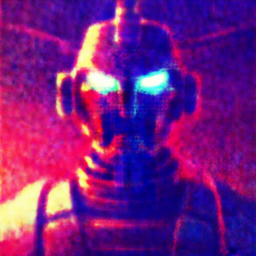

Image X


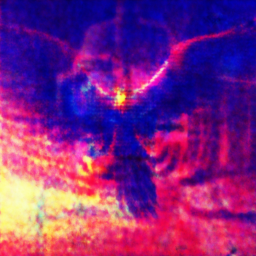

Image Y


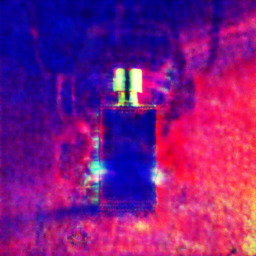

Image Z


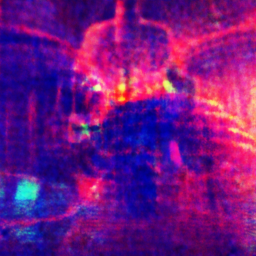

In [ ]:
print('Image W')
rp.display_image(rp.as_numpy_image(learnable_image_w()))

print('Image X')
rp.display_image(rp.as_numpy_image(learnable_image_x()))

print('Image Y')
rp.display_image(rp.as_numpy_image(learnable_image_y()))

print('Image Z')
rp.display_image(rp.as_numpy_image(learnable_image_z()))

In [ ]:
def save_png(name, sub_folder, output_folder):
    folder=f"{output_folder}/{sub_folder}/{name}"
    if rp.path_exists(folder):
        folder+='_%i'%time.time()
    rp.make_directory(folder)
    ims_names=['ims_%04i.png'%i for i in range(len(ims))]
    with rp.SetCurrentDirectoryTemporarily(folder):
        rp.save_images(ims,ims_names,show_progress=True)
    print()
    print('Saved timelapse to folder:',repr(folder))


sub_folder = "Rotation_Overlays_MIKU_frog_photo2018_kitchen"
out = "/content/drive/MyDrive/Visual_Anagrams_2024CVPR/baselines/Burgert/outputs"
save_png('Rotation_Overlays_Mixed_Characters', sub_folder=sub_folder, output_folder=out) #You can give it a good custom name if you want!

Saving Images: Done! Did 10 items in 0:00:00.299989
rp.save_images: Done! Saved 10 images in 0.302 seconds

Saved timelapse to folder: '/content/drive/MyDrive/Visual_Anagrams_2024CVPR/baselines/Burgert/outputs/Rotation_Overlays_MIKU_frog_photo2018_kitchen/Rotation_Overlays_Mixed_Characters'


In [ ]:
def save_png(name, sub_folder, output_folder):
    folder=f"{output_folder}/{sub_folder}/{name}"
    if rp.path_exists(folder):
        folder+='_%i'%time.time()
    rp.make_directory(folder)
    ims_names=['ims_%04i.png'%i for i in range(len(ims))]
    with rp.SetCurrentDirectoryTemporarily(folder):
        rp.save_images(ims,ims_names,show_progress=True)
    print()
    print('Saved timelapse to folder:',repr(folder))


sub_folder = "Rotation_Overlays_phoenix_perfume_city"
out = "/content/drive/MyDrive/Visual_Anagrams_2024CVPR/baselines/Burgert/outputs"
save_png('Rotation_Overlays_Mixed_Characters', sub_folder=sub_folder, output_folder=out) #You can give it a good custom name if you want!

Saving Images: Done! Did 15 items in 0:00:00.418879
rp.save_images: Done! Saved 15 images in 0.421 seconds

Saved timelapse to folder: '/content/drive/MyDrive/Visual_Anagrams_2024CVPR/baselines/Burgert/outputs/Rotation_Overlays_phoenix_perfume_city/Rotation_Overlays_Mixed_Characters'


# Twisting Squares

In [ ]:
from rp import *
import numpy as np
import rp
import torch
import torch.nn as nn
import source.stable_diffusion as sd
from easydict import EasyDict
from source.learnable_textures import LearnableImageFourier
from source.stable_diffusion_labels import NegativeLabel
from itertools import chain
import time

In [ ]:
#SET YOUR PROMPTS HERE

prompt_a = "Hatsune Miku"
prompt_b = "A dog's face photograph 4k"

NUMBER_OF_SQUARES = 4 # A 4x4 twisting squares illusion

#Optional: Specify what you DON'T want to see
negative_prompt = 'blurry ugly'

print()
print('Negative prompt:',repr(negative_prompt))
print()
print('Chosen prompts:')
print('    prompt_a =', repr(prompt_a)) #This will be right-side up
print('    prompt_b =', repr(prompt_b)) #This will be upside-down


Negative prompt: 'blurry ugly'

Chosen prompts:
    prompt_a = 'Hatsune Miku'
    prompt_b = "A dog's face photograph 4k"


In [ ]:
# customized (optimized)
prompt_a = "A luminous digital painting of Kaworu Nagisa from Neon Genesis Evangelion, serene expression, soft ethereal glow, white hair, elegant pose, cinematic lighting, anime style, trending on ArtStation, 4k, masterpiece"
prompt_b = "A close-up ultra-detailed photograph of a cat's face with vivid eyes, soft fur texture, symmetrical, shallow depth of field, high contrast, natural lighting, 4k resolution, captured with DSLR"

NUMBER_OF_SQUARES = 4  # A 4x4 twisting squares illusion

# Optional: Specify what you DON'T want to see
negative_prompt = 'blurry, low-resolution, disfigured, ugly, bad anatomy, distorted face'

print()
print('Negative prompt:', repr(negative_prompt))
print()
print('Chosen prompts:')
print('    prompt_a =', repr(prompt_a))  # This will be right-side up
print('    prompt_b =', repr(prompt_b))  # This will be upside-down



Negative prompt: 'blurry, low-resolution, disfigured, ugly, bad anatomy, distorted face'

Chosen prompts:
    prompt_a = 'A luminous digital painting of Kaworu Nagisa from Neon Genesis Evangelion, serene expression, soft ethereal glow, white hair, elegant pose, cinematic lighting, anime style, trending on ArtStation, 4k, masterpiece'
    prompt_b = "A close-up ultra-detailed photograph of a cat's face with vivid eyes, soft fur texture, symmetrical, shallow depth of field, high contrast, natural lighting, 4k resolution, captured with DSLR"


In [ ]:
# customized (optimized)
prompt_a = "Owls"
prompt_b = "Cats"

NUMBER_OF_SQUARES = 4  # A 4x4 twisting squares illusion

# Optional: Specify what you DON'T want to see
negative_prompt = 'blurry, ugly, distorted face, broken pieces'

print()
print('Negative prompt:', repr(negative_prompt))
print()
print('Chosen prompts:')
print('    prompt_a =', repr(prompt_a))  # This will be right-side up
print('    prompt_b =', repr(prompt_b))  # This will be upside-down



Negative prompt: 'blurry, ugly, distorted face, broken pieces'

Chosen prompts:
    prompt_a = 'Owls'
    prompt_b = 'Cats'


## Launcher Process

In [ ]:
if 's' not in dir():
    #You can select the original Stable Diffusion 1.5 or some dreambooth of it
    model_name="CompVis/stable-diffusion-v1-4"
    model_name="runwayml/stable-diffusion-v1-5"
    # model_name="nitrosocke/Arcane-Diffusion"
    gpu=rp.select_torch_device()
    s=sd.StableDiffusion(gpu,model_name)
device=s.device

In [ ]:
label_a = NegativeLabel(prompt_a,negative_prompt)
label_b = NegativeLabel(prompt_b,negative_prompt)

In [ ]:
#Image Parametrization and Initialization (this section takes vram)

#Select Learnable Image Size (this has big VRAM implications!):
#Note: We use implicit neural representations for better image quality
#They're previously used in our paper "TRITON: Neural Neural Textures make Sim2Real Consistent" (see tritonpaper.github.io)
# ... and that representation is based on Fourier Feature Networks (see bmild.github.io/fourfeat)
learnable_image_maker = lambda: LearnableImageFourier(height=256,width=256,num_features=256,hidden_dim=256,scale=10).to(s.device);SIZE=256

image=learnable_image_maker()

In [ ]:
import torch
import torch.nn.functional as F

def rotate_tiles(image, num_divisions=NUMBER_OF_SQUARES):
    image=as_torch_image(image)
    # Assuming image is a tensor of shape (num_channels, height, width)
    num_channels, height, width = image.shape

    tile_size=width//num_divisions

    # Calculate the number of tiles in each dimension
    tiles_x = width // tile_size
    tiles_y = height // tile_size

    # Initialize an output tensor
    output = torch.zeros_like(image)

    for x in range(tiles_x):
        for y in range(tiles_y):
            # Extract the tile
            tile = image[:, y*tile_size:(y+1)*tile_size, x*tile_size:(x+1)*tile_size]

            # Check if the tile should be rotated 90 or -90 degrees (checker pattern)
            if (x + y) % 2 == 0:
                # Rotate 90 degrees
                tile = tile.rot90(1, [1, 2])
            else:
                # Rotate -90 degrees
                tile = tile.rot90(-1, [1, 2])

            # Place the rotated tile back in the output tensor
            output[:, y*tile_size:(y+1)*tile_size, x*tile_size:(x+1)*tile_size] = tile

    return output

learnable_image_a=lambda: image()
learnable_image_b=lambda: rotate_tiles(image()) #Upside-down

optim=torch.optim.SGD(image.parameters(),lr=1e-4)

In [ ]:
labels=[label_a,label_b]
learnable_images=[learnable_image_a,learnable_image_b]

#The weight coefficients for each prompt. For example, if we have [0,1], then only the upside-down mode will be optimized
weights=[1,1]

weights=rp.as_numpy_array(weights)
weights=weights/weights.sum()
weights=weights*len(weights)

In [ ]:
#For saving a timelapse
# it gets some errors here but it will be worked
ims=[]

def get_display_image():
    return rp.tiled_images(
        [
            rp.as_numpy_image(learnable_image_a()),
            rp.as_numpy_image(learnable_image_b()),
        ],
        length=len(learnable_images),
        border_thickness=0,
    )

In [ ]:
NUM_ITER=5000

#Set the minimum and maximum noise timesteps for the dream loss (aka score distillation loss)
s.max_step=MAX_STEP=990
s.min_step=MIN_STEP=10

television = rp.JupyterDisplayChannel()
television.display()

display_eta=rp.eta(NUM_ITER, title='Status')

DISPLAY_INTERVAL = 200

print('Every %i iterations we display an image in the form [image_a, image_b], where'%DISPLAY_INTERVAL)
print('    image_a = (the right-side up image)')
print('    image_b = (image_a, but upside down)')
print()
print('Interrupt the kernel at any time to return the currently displayed image')
print('You can run this cell again to resume training later on')
print()
print('Please expect this to take quite a while to get good images (especially on the slower Colab GPU\'s)! The longer you wait the better they\'ll be')

try:
    for iter_num in range(NUM_ITER):
        display_eta(iter_num) #Print the remaining time

        preds=[]
        for label,learnable_image,weight in rp.random_batch(list(zip(labels,learnable_images,weights)), batch_size=1):
            pred=s.train_step(
                label.embedding,
                learnable_image()[None],

                #PRESETS (uncomment one):
                noise_coef=.1*weight,guidance_scale=100,#10
                # noise_coef=0,image_coef=-.01,guidance_scale=50,
                # noise_coef=0,image_coef=-.005,guidance_scale=50,
                # noise_coef=.1,image_coef=-.010,guidance_scale=50,
                # noise_coef=.1,image_coef=-.005,guidance_scale=50,
                # noise_coef=.1*weight, image_coef=-.005*weight, guidance_scale=50,
            )
            preds+=list(pred)

        with torch.no_grad():
            if iter_num and not iter_num%(DISPLAY_INTERVAL*50):
                #Wipe the slate every 50 displays so they don't get cut off
                from IPython.display import clear_output
                clear_output()

            if not iter_num%(DISPLAY_INTERVAL//4):
                im = get_display_image()
                ims.append(im)
                television.update(im)

                if not iter_num%DISPLAY_INTERVAL:
                    rp.display_image(im)

        optim.step()
        optim.zero_grad()
except KeyboardInterrupt:
    print()
    print('Interrupted early at iteration %i'%iter_num)
    im = get_display_image()
    ims.append(im)
    rp.display_image(im)

Output hidden; open in https://colab.research.google.com to view.

Unsolved Image:


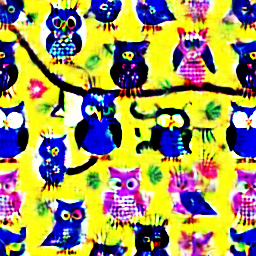

Solved Image:


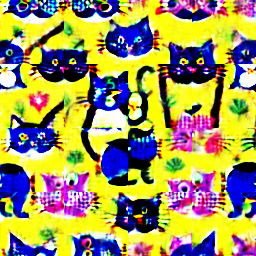

In [ ]:
print('Unsolved Image:')
rp.display_image(rp.as_numpy_image(learnable_image_a()))

print('Solved Image:')
rp.display_image(rp.as_numpy_image(learnable_image_b()))

In [ ]:
def save_png(name, sub_folder, output_folder):
    folder=f"{output_folder}/{sub_folder}/{name}"
    if rp.path_exists(folder):
        folder+='_%i'%time.time()
    rp.make_directory(folder)
    ims_names=['ims_%04i.png'%i for i in range(len(ims))]
    with rp.SetCurrentDirectoryTemporarily(folder):
        rp.save_images(ims,ims_names,show_progress=True)
    print()
    print('Saved timelapse to folder:',repr(folder))


sub_folder = "Twisting_Squares_MIKU_DOG"
out = "/content/drive/MyDrive/Visual_Anagrams_2024CVPR/baselines/Burgert/outputs"
save_png('Twisting_Squares_Mixed_Characters', sub_folder=sub_folder, output_folder=out) #You can give it a good custom name if you want!

Saving Images: Done! Did 100 items in 0:00:01.001138
rp.save_images: Done! Saved 100 images in 1.005 seconds

Saved timelapse to folder: '/content/drive/MyDrive/Visual_Anagrams_2024CVPR/baselines/Burgert/outputs/Twisting_Squares_MIKU_DOG/Twisting_Squares_Mixed_Characters'


In [ ]:
def save_png(name, sub_folder, output_folder):
    folder=f"{output_folder}/{sub_folder}/{name}"
    if rp.path_exists(folder):
        folder+='_%i'%time.time()
    rp.make_directory(folder)
    ims_names=['ims_%04i.png'%i for i in range(len(ims))]
    with rp.SetCurrentDirectoryTemporarily(folder):
        rp.save_images(ims,ims_names,show_progress=True)
    print()
    print('Saved timelapse to folder:',repr(folder))


sub_folder = "Twisting_Squares_Kaworu_Nagisa_CAT"
out = "/content/drive/MyDrive/Visual_Anagrams_2024CVPR/baselines/Burgert/outputs"
save_png('Twisting_Squares_Mixed_Characters', sub_folder=sub_folder, output_folder=out) #You can give it a good custom name if you want!

Saving Images: Done! Did 100 items in 0:00:00.724600
rp.save_images: Done! Saved 100 images in 0.728 seconds

Saved timelapse to folder: '/content/drive/MyDrive/Visual_Anagrams_2024CVPR/baselines/Burgert/outputs/Twisting_Squares_Kaworu_Nagisa_CAT/Twisting_Squares_Mixed_Characters'


In [ ]:
def save_png(name, sub_folder, output_folder):
    folder=f"{output_folder}/{sub_folder}/{name}"
    if rp.path_exists(folder):
        folder+='_%i'%time.time()
    rp.make_directory(folder)
    ims_names=['ims_%04i.png'%i for i in range(len(ims))]
    with rp.SetCurrentDirectoryTemporarily(folder):
        rp.save_images(ims,ims_names,show_progress=True)
    print()
    print('Saved timelapse to folder:',repr(folder))


sub_folder = "Twisting_Squares_OWL_CAT"
out = "/content/drive/MyDrive/Visual_Anagrams_2024CVPR/baselines/Burgert/outputs"
save_png('Twisting_Squares_Mixed_Characters', sub_folder=sub_folder, output_folder=out) #You can give it a good custom name if you want!

Saving Images: Done! Did 227 items in 0:00:01.907429
rp.save_images: Done! Saved 227 images in 1.911 seconds

Saved timelapse to folder: '/content/drive/MyDrive/Visual_Anagrams_2024CVPR/baselines/Burgert/outputs/Twisting_Squares_OWL_CAT/Twisting_Squares_Mixed_Characters'
